# 💳 FINANCIAL FRAUD DETECTION DATASET


# Objective

***The objective of this Exploratory Data Analysis (EDA) is to analyze financial transaction data to understand transaction behavior, identify fraudulent activities, evaluate transaction patterns, assess data quality, and generate business insights that support fraud detection, financial risk management, and data-driven decision-making. The project also aims to prepare clean and reliable data for SQL analysis, Power BI dashboard development, and basic machine learning.***

# Dataset Information

***Dataset Name: PaySim - Financial Fraud Detection Dataset***

***Domain: Banking & Financial Transactions***

***Total Records: (We will calculate using df.shape[0] after loading the dataset.)***

***Total Columns: 11***

***Columns: step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig, nameDest, oldbalanceDest, newbalanceDest, isFraud, isFlaggedFraud***

***Target Variable: isFraud***


# Work Flow

***1. Project Objective***

⬇️

***2. Dataset Information***

⬇️

***3. Business Understanding***

⬇️

***4. Import Required Libraries***

⬇️

***5. Load Dataset***

⬇️

***6. Basic Data Inspection : 
Display First 5 Records,
Display Last 5 Records,
Random Sample,
Dataset Shape,
Dataset Information,
Column Names,
Data Types,
Summary Statistics,
Check Memory Usage***

⬇️

***7. Data Cleaning : 
Handle Missing Values,
Check Duplicate Records,
Validate Data Types,
Check Unique Values,
Validate Transaction Amoun,t
Validate Sender & Receiver Balances,
Check Fraud Label Consistency***

⬇️

***8. Exploratory Data Analysis (EDA)***


⬇️

***9. Feature Engineering***


⬇️

***10. Basic Machine Learning***


⬇️

***11. Key Findings***


⬇️

***12. Business Recommendations***


⬇️

***13. Conclusion***


In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load Dataset
df = pd.read_csv(r"C:\Users\Arpit\Downloads\PS_20174392719_1491204439457_log.csv.zip")

In [4]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [8]:
# 5 rows 
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
# Dataset Shape
df.shape

(6362620, 11)

Total Records: 6,362,620


Total Columns: 11

In [11]:
# Check the Datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


Dataset Summary

Total Records: 6,362,620

Total Columns: 11

Numerical Columns: 8

Categorical Columns: 3

Target Variable: isFraud

Data Types: Integer, Float, Object



In [6]:
# Check Missing Values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [12]:
# Check the missing Values 
df.duplicated().sum()
#The dataset contains no duplicate records.
#No duplicate removal is required.

0

In [13]:
# Check Data Types
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [7]:
# Rename Columns

df.rename(columns={
    'type': 'transaction_type',
    'amount': 'transaction_amount',
    'nameOrig': 'sender_account',
    'oldbalanceOrg': 'sender_balance_before',
    'newbalanceOrig': 'sender_balance_after',
    'nameDest': 'receiver_account',
    'oldbalanceDest': 'receiver_balance_before',
    'newbalanceDest': 'receiver_balance_after',
    'isFraud': 'is_fraud',
    'isFlaggedFraud': 'is_flagged_fraud'
}, inplace=True)

In [8]:
df.columns

Index(['step', 'transaction_type', 'transaction_amount', 'sender_account',
       'sender_balance_before', 'sender_balance_after', 'receiver_account',
       'receiver_balance_before', 'receiver_balance_after', 'is_fraud',
       'is_flagged_fraud'],
      dtype='object')

I renamed the columns to make them more descriptive and consistent using the snake_case naming convention. 
This improves code readability, makes SQL queries easier to write, and helps create clearer dashboards.

In [16]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
transaction_amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
sender_balance_before,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
sender_balance_after,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
receiver_balance_before,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
receiver_balance_after,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
is_fraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
is_flagged_fraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [17]:
# Transaction Type Count
df['transaction_type'].value_counts()

transaction_type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [19]:
# Transaction Type Percentage
round(df['transaction_type'].value_counts(normalize=True) * 100, 2)

transaction_type
CASH_OUT    35.17
PAYMENT     33.81
CASH_IN     21.99
TRANSFER     8.38
DEBIT        0.65
Name: proportion, dtype: float64

# EXPLORATORY DATASET ANALYSIS
---------------------

**Transaction Type Distribution**

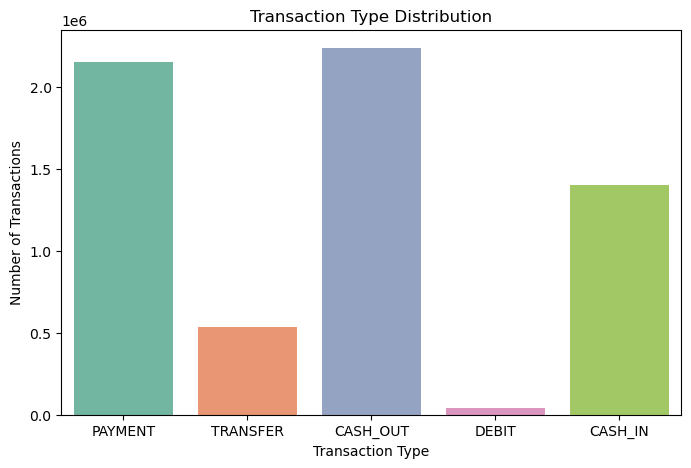

In [20]:

plt.figure(figsize=(8,5))

sns.countplot(
    x='transaction_type',
    data=df,
    palette='Set2'
)

plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')

plt.show()

**Fraud vs Genuine Transaction Distribution**

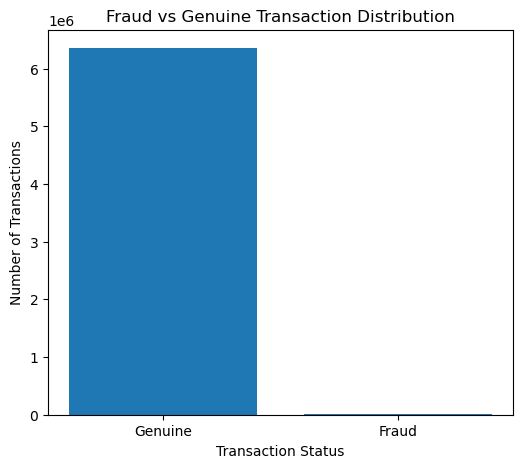

In [9]:
# Fraud vs Genuine Transaction Distribution

fraud_count = df['is_fraud'].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    ['Genuine', 'Fraud'],
    fraud_count.values
)

plt.title('Fraud vs Genuine Transaction Distribution')
plt.xlabel('Transaction Status')
plt.ylabel('Number of Transactions')

plt.show()

Insight: The dataset is highly imbalanced, with genuine transactions significantly dominating fraudulent transactions.
Fraudulent transactions represent only approximately 0.13% of total transactions, indicating that fraud is a rare event in the dataset. 
This class imbalance should be considered during machine learning model evaluation.

**Fraud Percentage**

In [13]:

fraud_percentage = (
    df['is_fraud'].value_counts(normalize=True) * 100
).round(2)

fraud_percentage

is_fraud
0    99.87
1     0.13
Name: proportion, dtype: float64

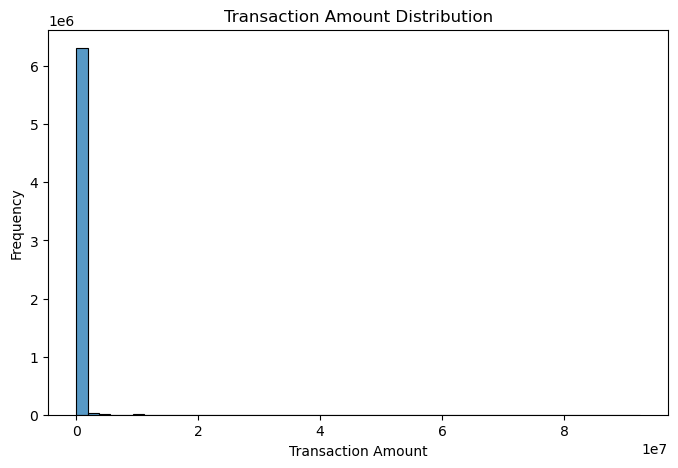

In [16]:
# Transaction Amount Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='transaction_amount',
    bins=50
)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

 Insight:
The transaction amount distribution is highly right-skewed. Most transactions are concentrated at lower amount values, 
while a small number of transactions involve extremely high amounts. 
These high-value transactions create a long right tail and may represent potential outliers that require further analysis.

I observed that the transaction amount distribution was highly right-skewed. Most transactions were concentrated at lower amounts, 
while a small number of transactions had extremely high values. 
Therefore, I further investigated high-value transactions and potential outliers instead of directly removing them.

***Average Transaction Amount by Transaction Type***

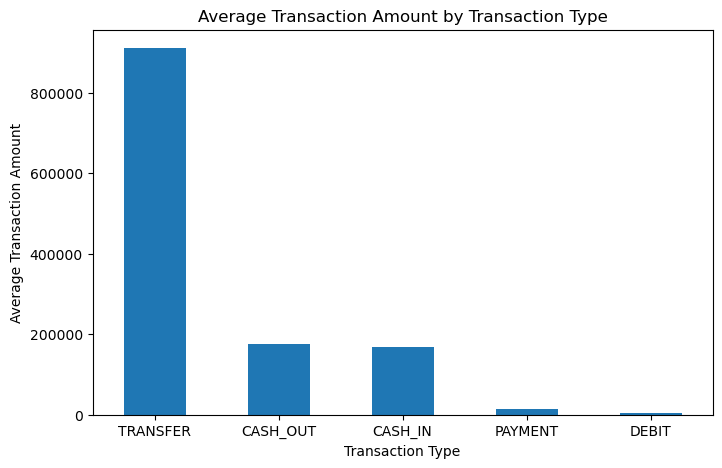

In [22]:
# Average Transaction Amount by Transaction Type

avg_amount = (
    df.groupby('transaction_type')['transaction_amount']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

avg_amount.plot(kind='bar')

plt.title('Average Transaction Amount by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=0)

plt.show()

***Fraud by Transaction Type***

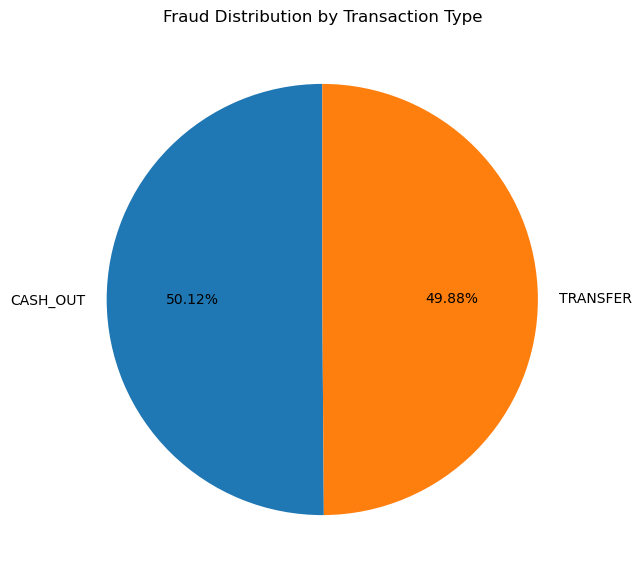

In [26]:
# Filter Fraud Transactions
fraud_data = df[df['is_fraud'] == 1]

# Fraud Count by Transaction Type
fraud_by_type = fraud_data['transaction_type'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    fraud_by_type.values,
    labels=fraud_by_type.index,
    autopct='%1.2f%%',
    startangle=90
)

plt.title('Fraud Distribution by Transaction Type')

plt.show()

Insight

Fraudulent transactions are exclusively concentrated in CASH_OUT and TRANSFER transaction types. 
CASH_OUT accounts for approximately 50.12% of total fraudulent transactions, while TRANSFER contributes approximately 49.88%. 
No fraudulent transactions are observed in PAYMENT, CASH_IN, or DEBIT transaction types.

**Fraud Rate by Transaction Type**

In [27]:
# Fraud Rate by Transaction Type

fraud_rate_by_type = (
    df.groupby('transaction_type')['is_fraud']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fraud_rate_by_type

transaction_type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: is_fraud, dtype: float64

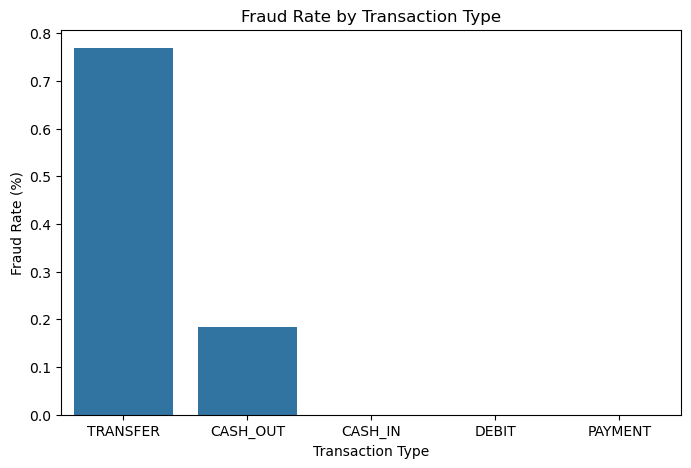

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=fraud_rate_by_type.index,
    y=fraud_rate_by_type.values
)

plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')

plt.xticks(rotation=0)
plt.show()

***Filter Fraud Transactions***

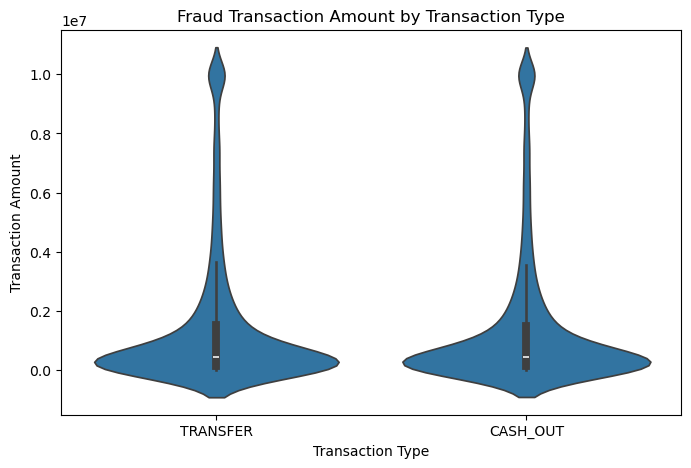

In [29]:
# Filter Fraud Transactions
fraud_data = df[df['is_fraud'] == 1]

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=fraud_data,
    x='transaction_type',
    y='transaction_amount'
)

plt.title('Fraud Transaction Amount by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount')

plt.show()

Insights

Fraudulent TRANSFER and CASH_OUT transactions show very similar transaction amount distributions.
Most fraudulent transactions are concentrated in the lower amount range, while a smaller number of fraud cases involve extremely high transaction amounts. 
Both transaction types display a long upper tail, indicating the presence of high-value fraudulent transactions.

**Fraud Trend by Transaction Step**

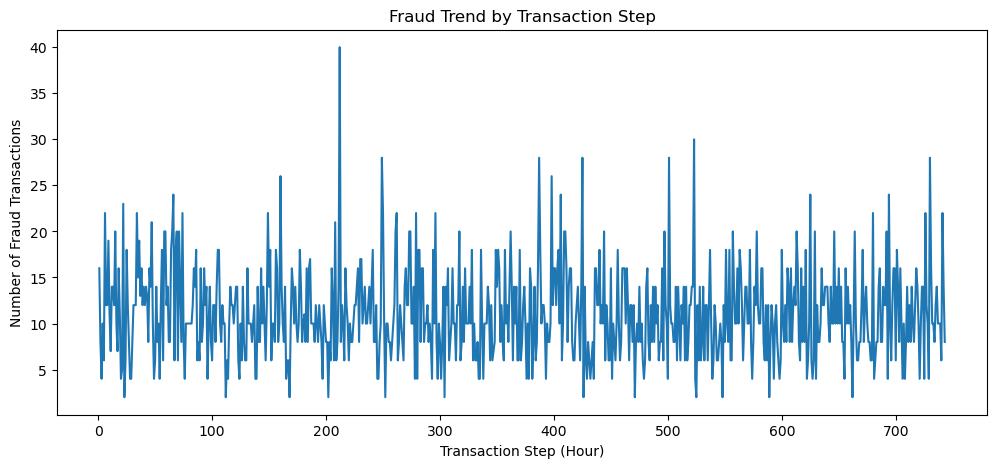

In [34]:
fraud_trend = (
    df[df['is_fraud'] == 1]
    .groupby('step')
    .size()
)

plt.figure(figsize=(12, 5))

plt.plot(
    fraud_trend.index,
    fraud_trend.values
)

plt.title('Fraud Trend by Transaction Step')
plt.xlabel('Transaction Step (Hour)')
plt.ylabel('Number of Fraud Transactions')

plt.show()

Insight

Fraudulent transactions fluctuate across different transaction steps, with several noticeable spikes in fraud activity.
The fraud pattern is not constant over time, indicating that certain simulation periods experience higher fraud activity than others.

***Actual Fraud vs Flagged Fraud***

In [37]:
# Actual Fraud vs Flagged Fraud

fraud_comparison = pd.DataFrame({
    'Category': ['Actual Fraud', 'Flagged Fraud'],
    'Count': [
        df['is_fraud'].sum(),
        df['is_flagged_fraud'].sum()
    ]
})

fraud_comparison

,Category,Count
0,Actual Fraud,8213
1,Flagged Fraud,16


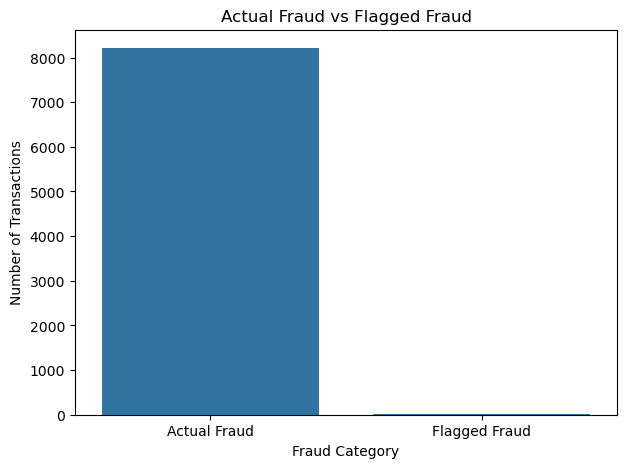

In [38]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=fraud_comparison,
    x='Category',
    y='Count'
)

plt.title('Actual Fraud vs Flagged Fraud')
plt.xlabel('Fraud Category')
plt.ylabel('Number of Transactions')

plt.show()

Insight: A large gap is observed between actual fraudulent transactions and transactions flagged by the existing fraud rule. 
The dataset contains approximately 8,213 actual fraud cases, while only 16 transactions were flagged.
This indicates that the flagged-fraud indicator has very limited coverage compared with the total number of actual fraud cases.

***Actual Fraud vs Flagged Fraud Crosstab***

In [41]:
# Actual Fraud vs Flagged Fraud Crosstab

fraud_flag_crosstab = pd.crosstab(
    df['is_fraud'],
    df['is_flagged_fraud']
)

fraud_flag_crosstab

is_flagged_fraud,0,1
is_fraud,,
0,6354407,0
1,8197,16


Insight: The existing fraud flagging indicator identified only 16 out of 8,213 actual fraudulent transactions, 
while 8,197 fraudulent transactions were not flagged. Additionally, no genuine transactions were incorrectly flagged. 
This indicates that the existing flagging indicator is highly limited in identifying the majority of fraud cases.

***Sender Balance Before vs After Fraud Transaction***

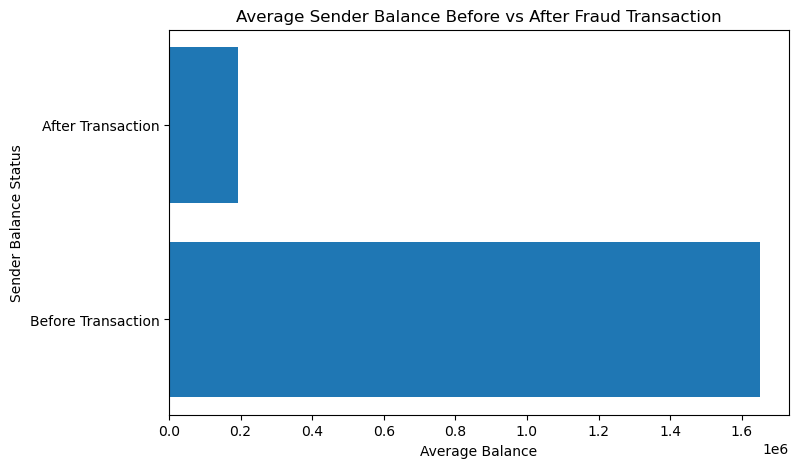

In [43]:
# Sender Balance Before vs After Fraud Transaction

fraud_sender_balance = fraud_data[
    ['sender_balance_before', 'sender_balance_after']
].mean()

plt.figure(figsize=(8, 5))

plt.barh(
    ['Before Transaction', 'After Transaction'],
    fraud_sender_balance.values
)

plt.title('Average Sender Balance Before vs After Fraud Transaction')
plt.xlabel('Average Balance')
plt.ylabel('Sender Balance Status')

plt.show()

Insight: The average sender balance decreases significantly after fraudulent transactions.
The average balance falls from approximately 1.65 million before the transaction to around 0.19 million after the transaction,
indicating a substantial reduction in sender balances during fraud cases.

***Receiver Balance Before vs After Fraud Transaction***

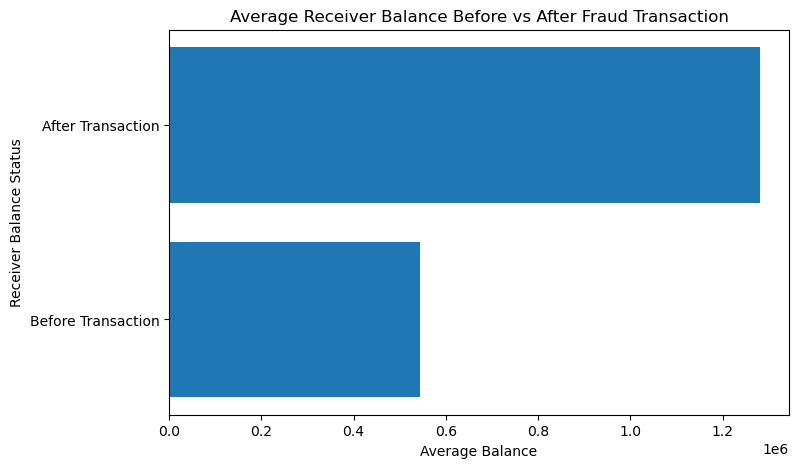

In [44]:
# Receiver Balance Before vs After Fraud Transaction

fraud_receiver_balance = fraud_data[
    ['receiver_balance_before', 'receiver_balance_after']
].mean()

plt.figure(figsize=(8, 5))

plt.barh(
    ['Before Transaction', 'After Transaction'],
    fraud_receiver_balance.values
)

plt.title('Average Receiver Balance Before vs After Fraud Transaction')
plt.xlabel('Average Balance')
plt.ylabel('Receiver Balance Status')

plt.show()

Insight: The average receiver balance increases significantly after fraudulent transactions, 
rising from approximately 0.55 million before the transaction to around 1.28 million after the transaction.
This indicates a substantial balance increase on the receiver side during fraud cases.

***Fraud Transaction Amount vs Sender Balance***

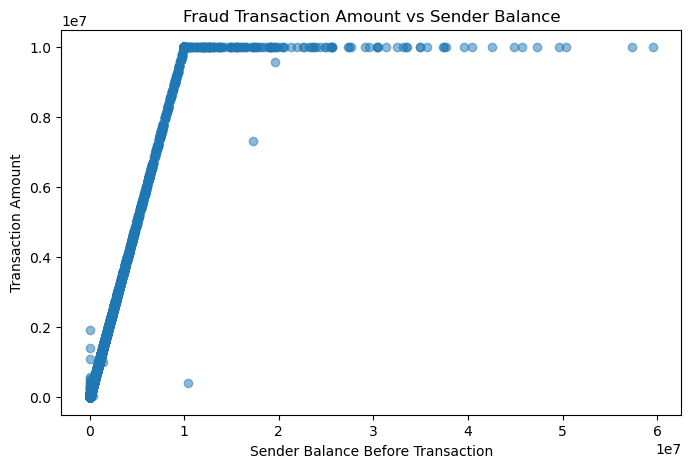

In [45]:
# Fraud Transaction Amount vs Sender Balance

plt.figure(figsize=(8, 5))

plt.scatter(
    fraud_data['sender_balance_before'],
    fraud_data['transaction_amount'],
    alpha=0.5
)

plt.title('Fraud Transaction Amount vs Sender Balance')
plt.xlabel('Sender Balance Before Transaction')
plt.ylabel('Transaction Amount')

plt.show()

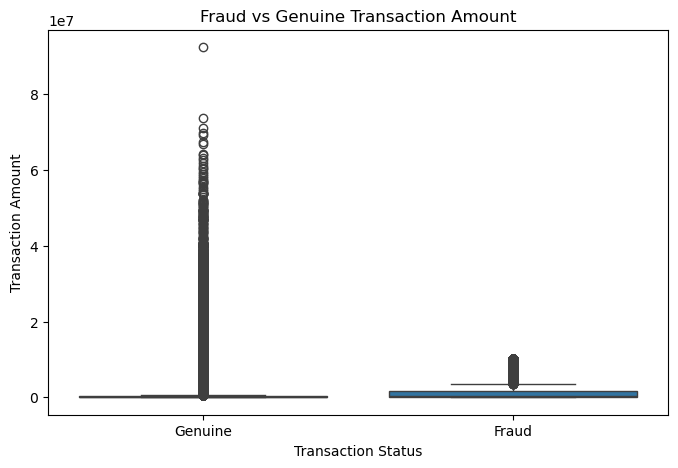

In [48]:
# Fraud vs Genuine Transaction Amount

plot_data = df.copy()

plot_data['fraud_status'] = plot_data['is_fraud'].map({
    0: 'Genuine',
    1: 'Fraud'
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_data,
    x='fraud_status',
    y='transaction_amount'
)

plt.title('Fraud vs Genuine Transaction Amount')
plt.xlabel('Transaction Status')
plt.ylabel('Transaction Amount')

plt.show()

Insight: Genuine transactions show a wider range of transaction amounts with numerous extreme high-value outliers. 
Fraudulent transactions display a comparatively more concentrated amount distribution. 
This indicates that high transaction amount alone cannot be considered a reliable indicator of fraud.

***Fraud Distribution by Amount Range***


In [50]:
# Fraud Distribution by Amount Range

fraud_data = fraud_data.copy()

fraud_data['amount_range'] = pd.cut(
    fraud_data['transaction_amount'],
    bins=[0, 100000, 500000, 1000000, float('inf')],
    labels=[
        'Low (0-1L)',
        'Medium (1L-5L)',
        'High (5L-10L)',
        'Very High (10L+)'
    ],
    include_lowest=True
)

fraud_amount_range = (
    fraud_data['amount_range']
    .value_counts()
    .sort_index()
)

fraud_amount_range

amount_range
Low (0-1L)          1707
Medium (1L-5L)      2642
High (5L-10L)       1158
Very High (10L+)    2706
Name: count, dtype: int64

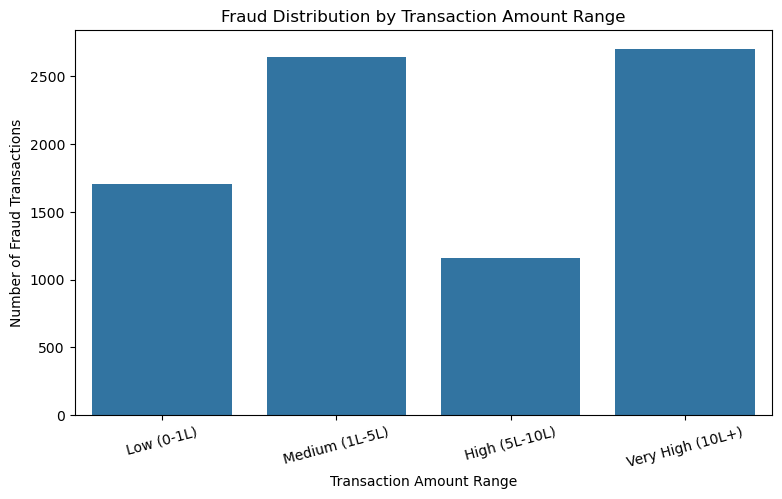

In [51]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=fraud_amount_range.index,
    y=fraud_amount_range.values
)

plt.title('Fraud Distribution by Transaction Amount Range')
plt.xlabel('Transaction Amount Range')
plt.ylabel('Number of Fraud Transactions')

plt.xticks(rotation=15)

plt.show()

Insight: Fraudulent transactions are distributed across all transaction amount ranges.
Very high-value transactions (10L+) record the highest number of fraud cases, followed closely by medium-value transactions (1L–5L). 
High-value transactions (5L–10L) show the lowest fraud count.
This indicates that fraud is not limited to a single transaction amount range.

***Correlation Heatmap***

In [53]:
# Select Numerical Columns

correlation_columns = [
    'step',
    'transaction_amount',
    'sender_balance_before',
    'sender_balance_after',
    'receiver_balance_before',
    'receiver_balance_after',
    'is_fraud',
    'is_flagged_fraud'
]

correlation_data = df[correlation_columns]

correlation_matrix = correlation_data.corr()

correlation_matrix

,step,transaction_amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,is_fraud,is_flagged_fraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
transaction_amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
sender_balance_before,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
sender_balance_after,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
receiver_balance_before,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
receiver_balance_after,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
is_fraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
is_flagged_fraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


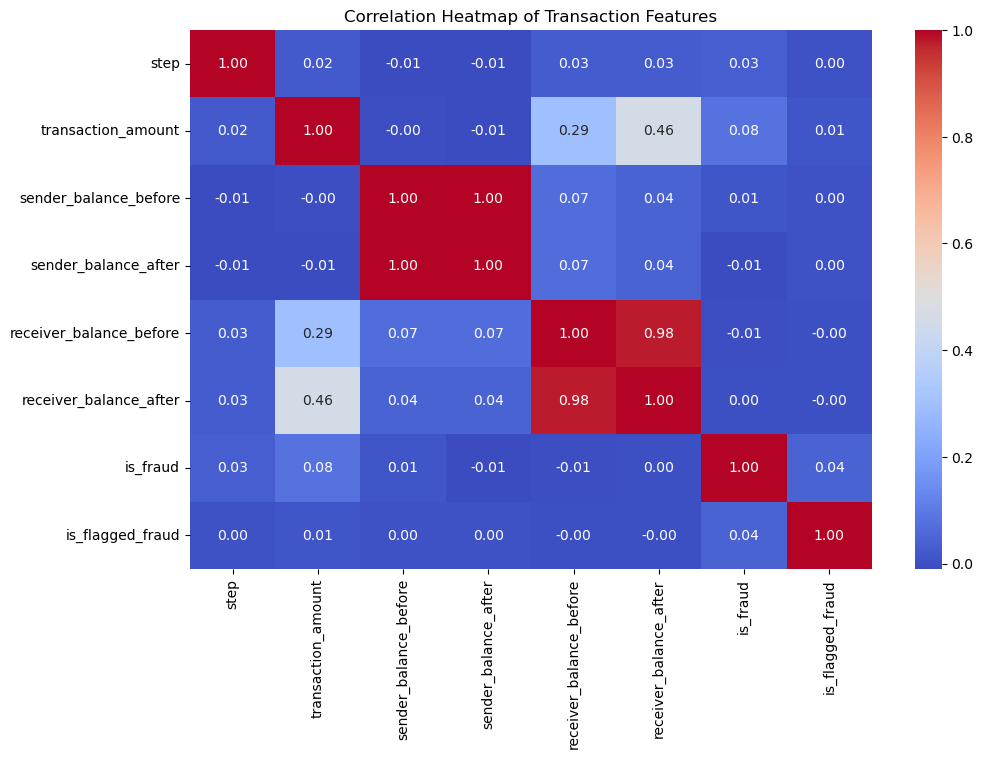

In [54]:
# Correlation Heatmap

plt.figure(figsize=(11, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Transaction Features')

plt.show()

Insight

Strong positive correlations are observed between sender balances before and after transactions and between receiver balances before and after transactions. However, 
the fraud indicator shows weak correlation with individual numerical features,
suggesting that fraud cannot be identified using a single feature alone and requires analysis of multiple transaction features together.

##  Basic Machine Learning

A basic machine learning classification model is applied to predict whether a transaction is fraudulent or 
genuine using multiple transaction and balance-related features.

In [57]:
# Select Features and Target

ml_data = df[
    [
        'transaction_type',
        'transaction_amount',
        'sender_balance_before',
        'sender_balance_after',
        'receiver_balance_before',
        'receiver_balance_after',
        'is_fraud'
    ]
].copy()

ml_data.head()

,transaction_type,transaction_amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,is_fraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [58]:
# Encode Transaction Type

ml_data = pd.get_dummies(
    ml_data,
    columns=['transaction_type'],
    drop_first=True,
    dtype=int
)

ml_data.head()

,transaction_amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,is_fraud,transaction_type_CASH_OUT,transaction_type_DEBIT,transaction_type_PAYMENT,transaction_type_TRANSFER
0,9839.64,170136.0,160296.36,0.0,0.0,0,0,0,1,0
1,1864.28,21249.0,19384.72,0.0,0.0,0,0,0,1,0
2,181.00,181.0,0.00,0.0,0.0,1,0,0,0,1
3,181.00,181.0,0.00,21182.0,0.0,1,1,0,0,0
4,11668.14,41554.0,29885.86,0.0,0.0,0,0,0,1,0


"I used one-hot encoding to convert the categorical transaction type into numerical binary features."

In [59]:
# Define Features and Target

X = ml_data.drop('is_fraud', axis=1)

y = ml_data['is_fraud']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (6362620, 9)
Target Shape: (6362620,)


In [60]:
# Split Data into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X Train Shape:", X_train.shape)
print("X Test Shape:", X_test.shape)
print("Y Train Shape:", y_train.shape)
print("Y Test Shape:", y_test.shape)

X Train Shape: (5090096, 9)
X Test Shape: (1272524, 9)
Y Train Shape: (5090096,)
Y Test Shape: (1272524,)


"I split the dataset into 80% training and 20% testing data and used stratification to maintain the fraud class proportion."

***Train Decision Tree Classifier***

In [62]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


"I used a Decision Tree because fraud detection is a classification problem, and I wanted a simple and interpretable baseline model.
It can handle numerical and encoded categorical features and does not require feature scaling.
I also used balanced class weights because the fraud class was highly imbalanced.

In [63]:
# Make Predictions

y_pred = model.predict(X_test)

print("Prediction Completed Successfully")

Prediction Completed Successfully


"After training the Decision Tree classifier, I used the test features to generate fraud predictions."

In [64]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[1237278,   33603],
       [      2,    1641]], dtype=int64)

[[TN, FP],

 [FN, TP]]

The Decision Tree model correctly identified 1,641 fraudulent transactions and missed only 2 actual fraud cases.
However, 33,603 genuine transactions were incorrectly classified as fraud. This indicates strong fraud detection coverage but a high number of false positive alerts, suggesting that the model needs improvement to reduce false alarms.

In [65]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Genuine', 'Fraud']
    )
)

              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.99   1270881
       Fraud       0.05      1.00      0.09      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.99      0.54   1272524
weighted avg       1.00      0.97      0.99   1272524



Insight: The Decision Tree achieved approximately 100% recall for the fraud class, identifying 1,641 out of 1,643 actual fraud cases.
However, fraud precision was only 5%, indicating a high number of false positive alerts. 
The fraud F1-score of 0.09 shows that the model requires further improvement to achieve a better balance between fraud detection and false alarms.

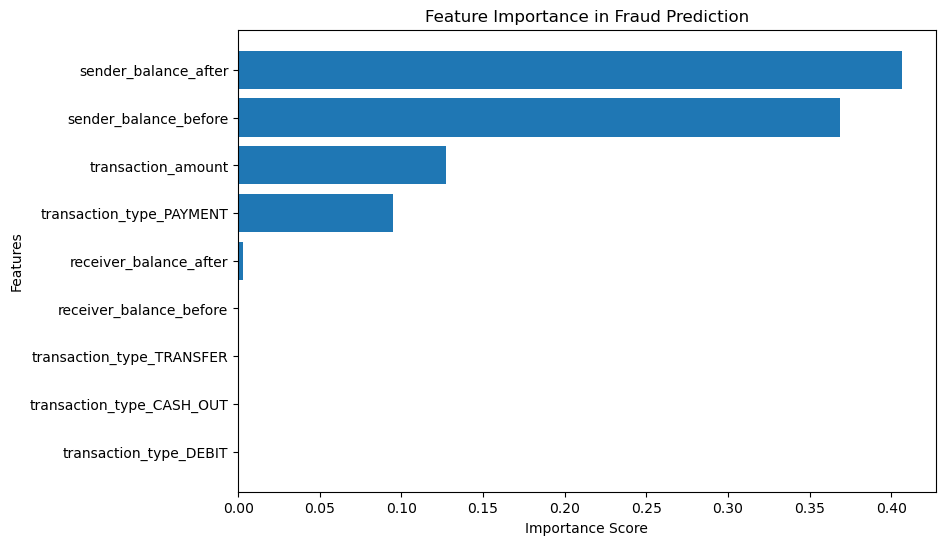

In [67]:
# Feature Importance

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance.index,
    feature_importance.values
)

plt.title('Feature Importance in Fraud Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()


Insight: Sender balance after the transaction and sender balance before the transaction were the most important features used by the Decision Tree model,
followed by transaction amount. This indicates that sender-side balance patterns played an important role in the model's fraud classification decisions.

## Machine Learning Findings

- A Decision Tree Classifier was used as a basic and interpretable baseline model for fraud classification.

- The dataset was split into 80% training data and 20% testing data using stratified sampling to maintain the fraud class proportion.

- Balanced class weights were applied because the dataset contained significantly fewer fraudulent transactions than genuine transactions.

- The model correctly identified 1,641 out of 1,643 actual fraud transactions in the test data and missed only 2 fraud cases.

- The model achieved approximately 100% recall for the fraud class, indicating strong fraud detection coverage.

- Fraud precision was only 5%, showing that the model generated a large number of false positive fraud alerts.

- The fraud F1-score was 0.09, indicating an imbalance between high fraud recall and low precision.

- Sender balance before and after the transaction were the most important features used by the Decision Tree, followed by transaction amount.

- The Decision Tree was treated as a baseline model and is not considered production-ready because the number of false positive alerts needs to be reduced.

# KEY FINDINGS

- Fraudulent transactions represent a very small proportion of the overall transaction dataset, indicating a highly imbalanced dataset.

- Fraud cases are concentrated in TRANSFER and CASH_OUT transaction types.

- Fraudulent transactions are distributed almost equally between TRANSFER and CASH_OUT transactions.

- The number of actual fraud cases is significantly higher than the number of transactions flagged by the existing fraud indicator.

- Out of 8,213 actual fraud cases, only 16 transactions were flagged, while 8,197 fraud cases were not flagged.

- Fraud activity fluctuates across transaction steps, with several sudden spikes in fraud counts.

- Fraud transactions show a significant decrease in the sender's average balance after the transaction.

- The receiver's average balance increases significantly after fraud transactions.

- Fraud cases are observed across all transaction amount ranges, with the highest fraud count in very high-value transactions (10L+), followed closely by medium-value transactions (1L–5L).

- Genuine transactions also contain extreme high-value transactions, indicating that transaction amount alone is not sufficient to identify fraud.

- Correlation analysis shows that individual numerical features have weak linear correlation with fraud, suggesting that multiple transaction features should be analyzed together for fraud detection.

# Business Recommendations
- Strengthen fraud monitoring for TRANSFER and CASH_OUT transactions because fraud cases are concentrated in these transaction types.

- Improve the existing fraud flagging mechanism, as only 16 out of 8,213 actual fraud cases were flagged.

- Monitor unusual sender balance reductions and receiver balance increases as potential transaction risk signals.

- Apply enhanced monitoring to very high-value transactions while also monitoring medium-value transactions, as fraud is present across multiple amount ranges.

- Avoid using transaction amount alone to identify fraud because genuine transactions also contain high-value transactions.

- Use multiple transaction features together to identify suspicious transaction patterns.

- Implement a machine learning-based fraud classification approach to support the existing rule-based fraud flagging indicator.


## 12. Conclusion

The financial fraud analysis identified important transaction and balance-related patterns associated with fraudulent activities. Fraud cases were highly imbalanced and were concentrated in TRANSFER and CASH_OUT transactions. The existing fraud flagging indicator detected only a very small number of actual fraud cases, highlighting limitations in the current flagging mechanism.

Exploratory Data Analysis showed that fraudulent transactions were present across multiple transaction amount ranges and that transaction amount alone was not sufficient to identify fraud. Sender and receiver balance patterns provided additional insights into transaction behavior.

A basic Decision Tree Classifier was implemented as an interpretable baseline model using multiple transaction and balance features. The model achieved approximately 97% overall accuracy and nearly 100% fraud recall, correctly identifying 1,641 out of 1,643 fraud cases in the test data. However, the fraud precision was only 5%, indicating a high number of false positive alerts.

The analysis concludes that fraud detection should not rely on a single transaction feature or overall accuracy alone. Multiple transaction features and fraud-focused evaluation metrics such as precision, recall, and F1-score should be considered. The baseline model requires further improvement to reduce false positive alerts before being considered for real-world deployment.


-------------------